In [29]:
# Librerias necesarias
# Matplotlib conf
import matplotlib.pyplot as plt
%matplotlib inline
params = {'legend.fontsize': 'x-large',
          'figure.figsize': (15, 5),
         'axes.labelsize': 'x-large',
         'axes.titlesize':'x-large',
         'xtick.labelsize':40,
         'ytick.labelsize': 40
}
plt.rcParams.update(params)
# Seaborn conf
import seaborn as sns
sns.set(style='darkgrid')
sns.set_palette(sns.color_palette("Blues"))

import sys

#Procesado de datos
import pandas as pd
import numpy as np
import operator

#Modelos
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfTransformer, TfidfVectorizer
from sklearn.feature_selection import SelectKBest, chi2

from sklearn.metrics import classification_report, accuracy_score
from sklearn.metrics import confusion_matrix

import warnings
warnings.filterwarnings('ignore')

In [30]:
training_set = pd.read_csv('../OffendES_dataset/offendes/train.csv')
print(f"Training set shape: {training_set.shape}, columns: {training_set.columns.tolist()}")
test_set = pd.read_csv('../OffendES_dataset/offendes/test.csv')
print(f"Test set shape: {test_set.shape}, columns: {test_set.columns.tolist()}")

Training set shape: (13368, 3), columns: ['comment_id', 'comment', 'label']
Test set shape: (3342, 3), columns: ['comment_id', 'comment', 'label']


In [31]:
# Inspeccionamos el aspecto del conjunto de entrenamiento
training_set.head(20)

,comment_id,comment,label
0,2081,Dalas: hace una pregunta retórica Turbobo: *...,NO
1,21214,Por qué no solamente le diste a una fundación ...,NO
2,40888,Te ves guapísima y brillante con ese nuevo loo...,NO
3,40790,Se esta hablando de que Ariana Grande esta rel...,NO
4,55889,¡¡HAGO REVIEWS DE SERIES Y PELIS!! ¿ Quieres e...,NO
5,41294,"YouTube ya no es como antes, como en esos tiem...",NO
6,33127,Entrar a YouTube después de un día de mierda y...,NOM
7,40612,"Oye y no se puede pagar el curso, hacerlo y de...",NO
8,22418,"Hombre, Javi, se sobreentiende que cuando dice...",NO
9,18623,Lo que habla del hate de él y badabun yo creo ...,NO


In [32]:
# Inspeccionamos el aspecto del conjunto de test
test_set.head(20)

,comment_id,comment,label
0,30327,Eres el mejor Dalas no hagas caso a los haters...,NO
1,32217,La ballena blanca es el único mamífero que a c...,NO
2,799,"Sisi,yo ya estoy harta de él,y pensar que me g...",NO
3,12385,No quiero ser hater ni criticar mira mas abajo...,NO
4,10931,"Lo que dice el Rubius es cierto, mucha gente a...",NO
5,45843,Es el primer video q no me gusta !! Jeje miare...,NO
6,41627,windy por favor >:v deja de gritar me esta la...,NO
7,10540,De aquí a comentar a ese maldito video,NO
8,25087,Te odio BUUUU FALSA,OFP
9,18286,Haz un video opinando de la empresa in cruises...,NO


In [33]:
unique_labels_train = training_set['label'].unique()
print(f'Unique labels in training set: {unique_labels_train}')
unique_labels_test = test_set['label'].unique()
print(f'Unique labels in test set: {unique_labels_test}')

assert set(unique_labels_train) == set(unique_labels_test), "Train and test sets have different labels"

Unique labels in training set: <ArrowStringArray>
['NO', 'NOM', 'OFP', 'OFG']
Length: 4, dtype: str
Unique labels in test set: <ArrowStringArray>
['NO', 'OFP', 'NOM', 'OFG']
Length: 4, dtype: str


In [34]:
# Mapping dictionary
label_mapping = {
    'OFP': 'Offensive',
    'OFG': 'Offensive',
    'NOM': 'No offensive',
    'NO':  'No offensive'
}

# Apply mapping to create the new column
training_set['joint_label'] = training_set['label'].map(label_mapping)
test_set['joint_label']     = test_set['label'].map(label_mapping)

In [35]:
unique_labels_train = training_set['joint_label'].unique()
print(f'Unique labels in training set: {unique_labels_train}')
unique_labels_test = test_set['joint_label'].unique()
print(f'Unique labels in test set: {unique_labels_test}')

assert set(unique_labels_train) == set(unique_labels_test), "Train and test sets have different labels"

Unique labels in training set: <ArrowStringArray>
['No offensive', 'Offensive']
Length: 2, dtype: str
Unique labels in test set: <ArrowStringArray>
['No offensive', 'Offensive']
Length: 2, dtype: str


In [36]:
accepted_labels = {'No offensive', 'Offensive'}
rows_with_problems = training_set[training_set.joint_label.isin(accepted_labels) == False]
rows_with_problems

,comment_id,comment,label,joint_label


In [37]:
dataset = pd.concat([training_set, test_set])
dataset.shape
dataset.columns

Index(['comment_id', 'comment', 'label', 'joint_label'], dtype='str')

([0, 1], [Text(0, 0, 'No offensive'), Text(1, 0, 'Offensive')])

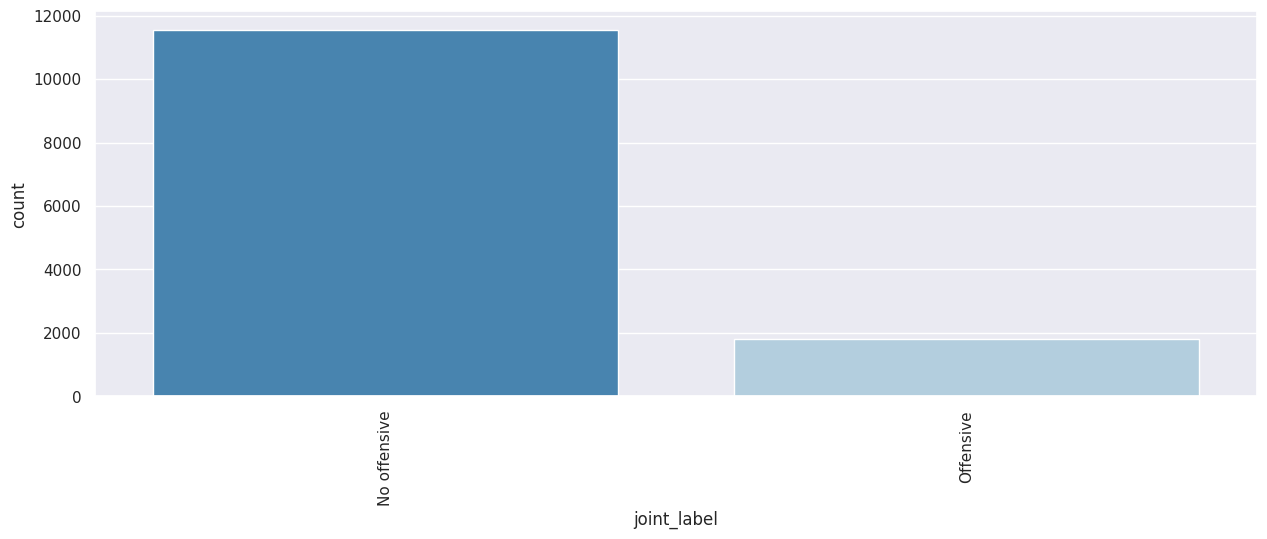

In [38]:
from collections import Counter
sns.countplot(data=training_set, x=training_set.joint_label, order=[x for x, count in sorted(Counter(training_set.joint_label).items(), key=lambda x: -x[1])], palette="Blues_r")
plt.xticks(rotation=90)

In [39]:
from matplotlib import interactive

# Agrupamos las reviews por su etiqueta
df = pd.DataFrame({"text": training_set.comment, "label": training_set.joint_label})
grouped = df.groupby(['label']).apply(lambda x: x['text'].sum())
grouped_df = pd.DataFrame({'label': grouped.index, 'text': grouped.values})

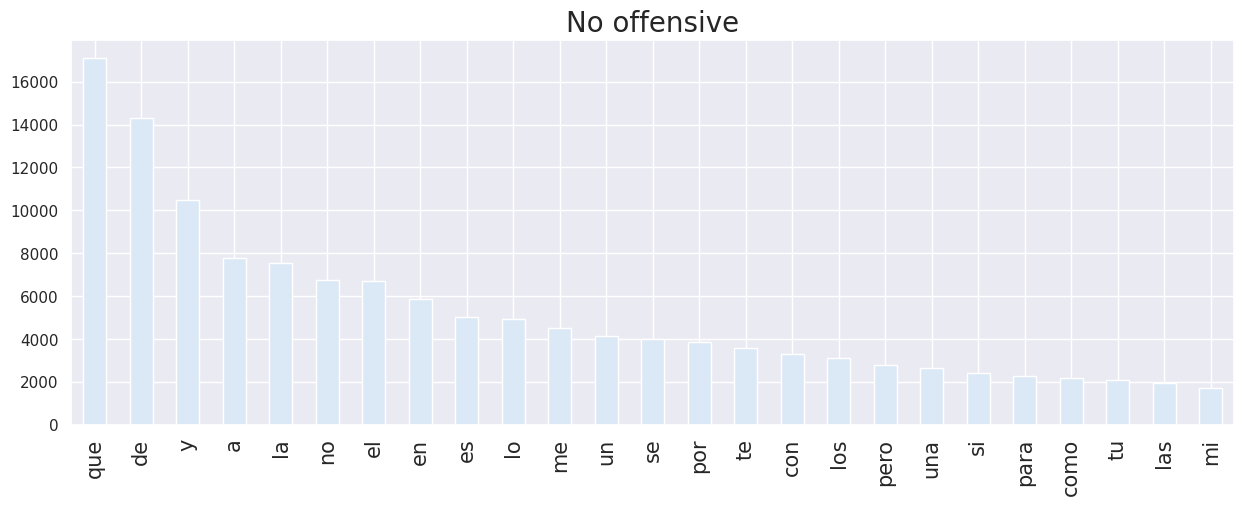

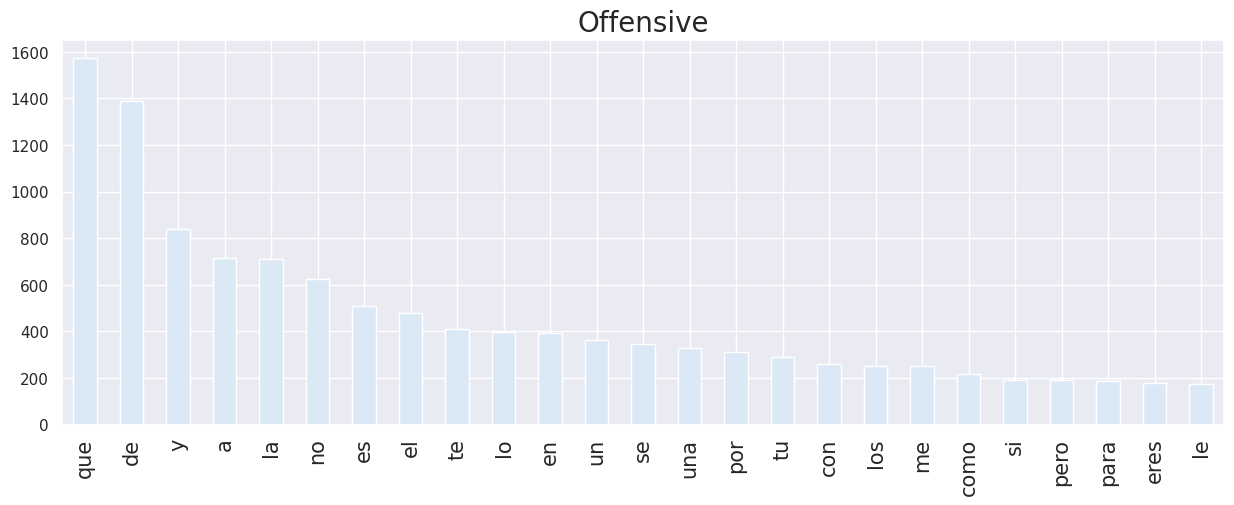

In [40]:
from nltk.tokenize import WhitespaceTokenizer
import matplotlib.pyplot as plt

tokenizer = WhitespaceTokenizer()

for ii, text in enumerate(grouped_df.text):
    tokens = tokenizer.tokenize(text)
    
    word_counts = pd.Series(tokens).value_counts().head(25)
    
    word_counts.plot(kind="bar")
    plt.title(grouped_df.label[ii], fontsize=20)
    plt.xticks(fontsize=15)
    plt.show()

pip install spacy
python -m spacy download es_core_news_sm

In [41]:
import spacy
import unicodedata
import re

# Load Spanish model once (disable unused components for speed)
nlp = spacy.load("es_core_news_sm", disable=["parser", "ner"])
spanish_stopwords = nlp.Defaults.stop_words


def remove_accents(text, keep_enye=True):
    if keep_enye:
        text = text.replace('ñ', '\0n').replace('Ñ', '\0N')
    nfkd = unicodedata.normalize('NFD', text)
    stripped = ''.join(c for c in nfkd if unicodedata.category(c) != 'Mn')
    if keep_enye:
        stripped = stripped.replace('\0n', 'ñ').replace('\0N', 'Ñ')
    return stripped


def process_text(raw_text):
    # Keep letters (with accents) so the lemmatizer works correctly
    pattern = "[^a-zA-ZáéíóúÁÉÍÓÚñÑüÜ]"
    letters_only = re.sub(pattern, " ", raw_text)

    # Lowercase
    text = letters_only.lower()

    # Lemmatize + remove stopwords with spaCy
    doc = nlp(text)
    lemmas = [
        token.lemma_
        for token in doc
        if token.lemma_ not in spanish_stopwords and token.lemma_.strip()
    ]

    # Remove accents AFTER lemmatization
    lemmas = [remove_accents(lemma) for lemma in lemmas]

    return " ".join(lemmas)

In [42]:
from tqdm import tqdm
tqdm.pandas()

dataset['clean_comment'] = dataset['comment'].progress_apply(lambda x: process_text(x))

100%|██████████| 16710/16710 [00:39<00:00, 421.31it/s]


In [43]:
dataset.head()

,comment_id,comment,label,joint_label,clean_comment
0,2081,Dalas: hace una pregunta retórica Turbobo: *...,NO,No offensive,da el pregunta retorico turbobo contar el vida...
1,21214,Por qué no solamente le diste a una fundación ...,NO,No offensive,distir fundacion dale mil dolar alguien probab...
2,40888,Te ves guapísima y brillante con ese nuevo loo...,NO,No offensive,guapisimo brillante look fantastico video apor...
3,40790,Se esta hablando de que Ariana Grande esta rel...,NO,No offensive,hablar arianar relacionado movida atentado ocu...
4,55889,¡¡HAGO REVIEWS DE SERIES Y PELIS!! ¿ Quieres e...,NO,No offensive,reviews serie pelis querer empezar serie empez...


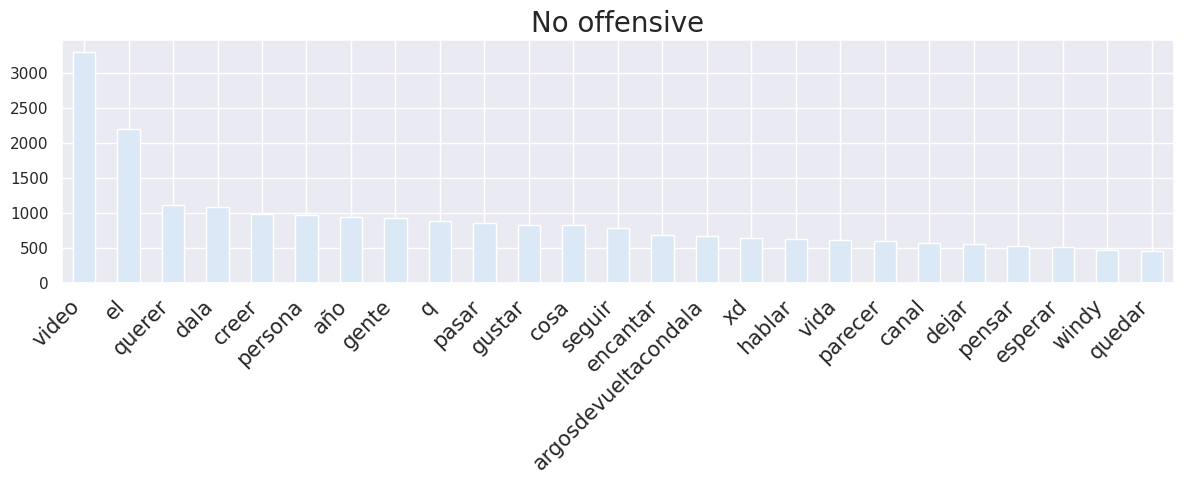

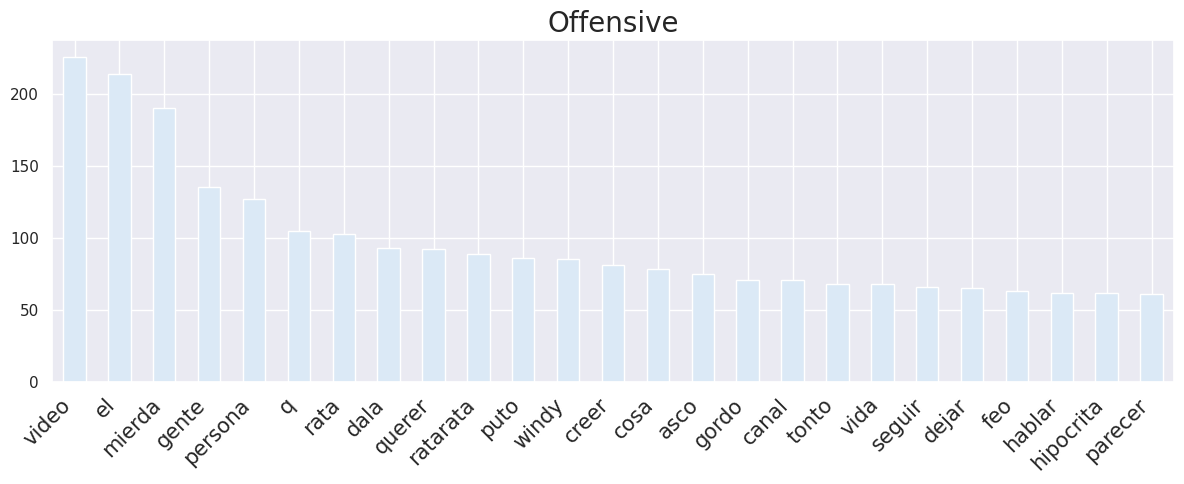

In [44]:
from nltk.tokenize import WhitespaceTokenizer
import matplotlib.pyplot as plt

df = pd.DataFrame({
    "text": dataset[0:len(training_set)].clean_comment,
    "CLASS": dataset[0:len(training_set)].joint_label
})

grouped_df = (
    df.groupby("CLASS")["text"]
      .apply(lambda x: " ".join(x.astype(str)))
      .reset_index()
)

tokenizer = WhitespaceTokenizer()

for ii, text in enumerate(grouped_df.text):
    tokens = tokenizer.tokenize(text)
    word_counts = pd.Series(tokens).value_counts().head(25)
    
    plt.figure(figsize=(12, 5))
    word_counts.plot(kind="bar")
    plt.title(grouped_df.CLASS[ii], fontsize=20)
    plt.xticks(fontsize=15, rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

In [45]:
X_train = dataset[0:len(training_set)][["comment_id", "clean_comment"]]
y_train = dataset[0:len(training_set)][["joint_label"]]

X_test = dataset[len(training_set):len(dataset)][["comment_id", "clean_comment"]]
y_test = dataset[len(training_set):len(dataset)][["joint_label"]]

In [46]:
from sklearn import preprocessing
le = preprocessing.LabelEncoder()
print(f"Values before encoding: {y_train.joint_label.values}")
le.fit(y_train.joint_label.values)
target_labels = le.classes_
encoded_y_train = le.transform(y_train.joint_label.values)
print(f"Labels after encoding: {encoded_y_train}")

print(f"Target labels: {target_labels}")

Values before encoding: <ArrowStringArray>
['No offensive', 'No offensive', 'No offensive', 'No offensive',
 'No offensive', 'No offensive', 'No offensive', 'No offensive',
 'No offensive', 'No offensive',
 ...
 'No offensive', 'No offensive', 'No offensive', 'No offensive',
 'No offensive', 'No offensive', 'No offensive', 'No offensive',
 'No offensive', 'No offensive']
Length: 13368, dtype: str
Labels after encoding: [0 0 0 ... 0 0 0]
Target labels: ['No offensive' 'Offensive']


In [47]:
print(encoded_y_train)
print(encoded_y_train.shape)

[0 0 0 ... 0 0 0]
(13368,)


In [48]:
count_vect = CountVectorizer(analyzer = "word")

train_features = count_vect.fit_transform(X_train.clean_comment)
test_features = count_vect.transform(X_test.clean_comment)

In [49]:
# Observemos el vocabulario
print('Longitud del vocabulario: ')
print(len(count_vect.vocabulary_))
print()
print("Observemos el vocabulario:")
print(count_vect.vocabulary_)
print()


Longitud del vocabulario: 
22969

Observemos el vocabulario:
{'da': 5406, 'el': 7141, 'pregunta': 16998, 'retorico': 18546, 'turbobo': 21473, 'contar': 4680, 'vida': 22090, 'año': 2148, 'llegar': 12739, 'xdd': 22678, 'distir': 6694, 'fundacion': 9307, 'dale': 5462, 'mil': 13925, 'dolar': 6781, 'alguien': 897, 'probablemente': 17166, 'siquiera': 19740, 'internet': 11343, 'quieres': 17684, 'ayudar': 2105, 'gente': 9517, 'excusa': 8389, 'video': 22102, 'seguidor': 19279, 'guapisimo': 9862, 'brillante': 2797, 'look': 12871, 'fantastico': 8713, 'aportar': 1458, 'hora': 10549, 'ejercicio': 7129, 'beso': 2473, 'hablar': 10021, 'arianar': 1608, 'relacionado': 18260, 'movida': 14336, 'atentado': 1858, 'ocurrio': 15095, 'concierto': 4458, 'pertenecer': 16267, 'mafia': 13047, 'arian': 1606, 'rechazar': 17972, 'titulo': 20971, 'dama': 5475, 'reina': 18235, 'isabel': 11489, 'ofrecer': 15157, 'reviews': 18606, 'serie': 19430, 'pelis': 16017, 'querer': 17640, 'empezar': 7290, 'bola': 2659, 'dejame': 

In [50]:
# Ejemplo original de una review
print("Original:")
print(dataset.comment.head()[0])
print()

# Ejemplo tras el preprocesado
print("Pre-procesado:")
print(X_train.clean_comment[0])
print()

# Convertimos la primera review
v0 = count_vect.transform([X_train.clean_comment[0]]).toarray()[0]
print('Convertido: ')
print(v0)
print()

# Es demasiado grande para observarlo, imprimimos su longitud
print('Longitud del vector: ')
print(len(v0))
print()

# ¿Cuántas palabras contiene la frase?
print('Número de palabras: ')
print(np.sum(v0))
print()


Original:
Dalas: hace una pregunta retórica   Turbobo: *se pone a contarle su vida a partir de los 15 años y de cómo llegó hasta hoy*   Xdd

Pre-procesado:
da el pregunta retorico turbobo contar el vida año llegar xdd

Convertido: 
[0 0 0 ... 0 0 0]

Longitud del vector: 
22969

Número de palabras: 
11



In [51]:
import numpy as np
from sklearn.model_selection import learning_curve

def plot_learning_curve(estimator, title, X, y, ylim=None, cv=None,
                        scoring='f1_macro',
                        train_sizes=np.linspace(.1, 1.0, 5)):
    """
    Generate a simple plot of the test and traning learning curve.

    Parameters
    ----------
    estimator : object type that implements the "fit" and "predict" methods
        An object of that type which is cloned for each validation.

    title : string
        Title for the chart.

    X : array-like, shape (n_samples, n_features)
        Training vector, where n_samples is the number of samples and
        n_features is the number of features.

    y : array-like, shape (n_samples) or (n_samples, n_features), optional
        Target relative to X for classification or regression;
        None for unsupervised learning.

    ylim : tuple, shape (ymin, ymax), optional
        Defines minimum and maximum yvalues plotted.

    cv : integer, cross-validation generator, optional
        If an integer is passed, it is the number of folds (defaults to 3).
        Specific cross-validation objects can be passed, see
        sklearn.cross_validation module for the list of possible objects

    scoring : string, optional
        Scoring metric for the learning curve (default: 'f1_macro').
    """

    plt.figure()
    train_sizes, train_scores, test_scores = learning_curve(
        estimator, X, y, cv=5, n_jobs=1, train_sizes=train_sizes,
        scoring=scoring)
    train_scores_mean = np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)
    test_scores_std = np.std(test_scores, axis=1)

    plt.fill_between(train_sizes, train_scores_mean - train_scores_std,
                     train_scores_mean + train_scores_std, alpha=0.1,
                     color="r")
    plt.fill_between(train_sizes, test_scores_mean - test_scores_std,
                     test_scores_mean + test_scores_std, alpha=0.1, color="g")
    plt.plot(train_sizes, train_scores_mean, 'o-', color="r",
             label="Training score")
    plt.plot(train_sizes, test_scores_mean, 'o-', color="g",
             label="Cross-validation score")

    plt.xlabel("Training examples")
    plt.ylabel(scoring)
    plt.legend(loc="best")
    plt.grid("on")
    if ylim:
        plt.ylim(ylim)
    plt.title(title)

In [52]:
def train_and_evaluate_classifier(X, yt, estimator, grid):
    """Train and Evaluate a estimator (defined as input parameter) on the given labeled data using F1 Macro."""

    # Se realiza validación cruzada estratificada sobre el clasificador seleccionado
    from sklearn.model_selection import StratifiedShuffleSplit
    cv = StratifiedShuffleSplit(n_splits=5, test_size=0.2, random_state=0)

    from sklearn.model_selection import GridSearchCV
    classifier = GridSearchCV(estimator=estimator, cv=cv, param_grid=grid,
                              scoring='f1_macro', error_score=0.0,
                              n_jobs=-1, verbose=5)
    
    # Entrenamiento
    print("Training model")
    classifier.fit(X, yt)

    # Puntuación de la validación cruzada
    print("CV-scores for each grid configuration")
    means = classifier.cv_results_['mean_test_score']
    stds = classifier.cv_results_['std_test_score']
    for mean, std, params in sorted(zip(means, stds, classifier.cv_results_['params']), key=lambda x: -x[0]):
        print("F1 Macro: %0.3f (+/-%0.03f) for params: %r" % (mean, std * 2, params))
    print()
        
    # Curva de aprendizaje
    print("Learning curve for the best estimator")
    title = 'Learning Curves (' + str(estimator.__class__).replace("'>", "").split(".")[-1] + ' )'
    plot_learning_curve(classifier.best_estimator_, title, X, yt, cv=cv)
    plt.show()
    
    return classifier

In [53]:
def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Confusion matrix',
                          cmap=plt.cm.Blues):
    """
    This function prints and plots the confusion matrix.
    Normalization can be applied by setting `normalize=True`.
    """
    import itertools
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print("Normalized confusion matrix")
    else:
        print('Confusion matrix, without normalization')
    plt.figure()
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.show()


# Entrenamiento de algoritmos de aprendizaje automático

## Naive Bayes

Training model
Fitting 5 folds for each of 1 candidates, totalling 5 fits
[CV 3/5] END ..................................., score=0.628 total time=   0.0s
[CV 2/5] END ..................................., score=0.668 total time=   0.0s
[CV 4/5] END ..................................., score=0.642 total time=   0.0s
[CV 1/5] END ..................................., score=0.647 total time=   0.0s
[CV 5/5] END ..................................., score=0.640 total time=   0.0s
CV-scores for each grid configuration
F1 Macro: 0.645 (+/-0.026) for params: {}

Learning curve for the best estimator


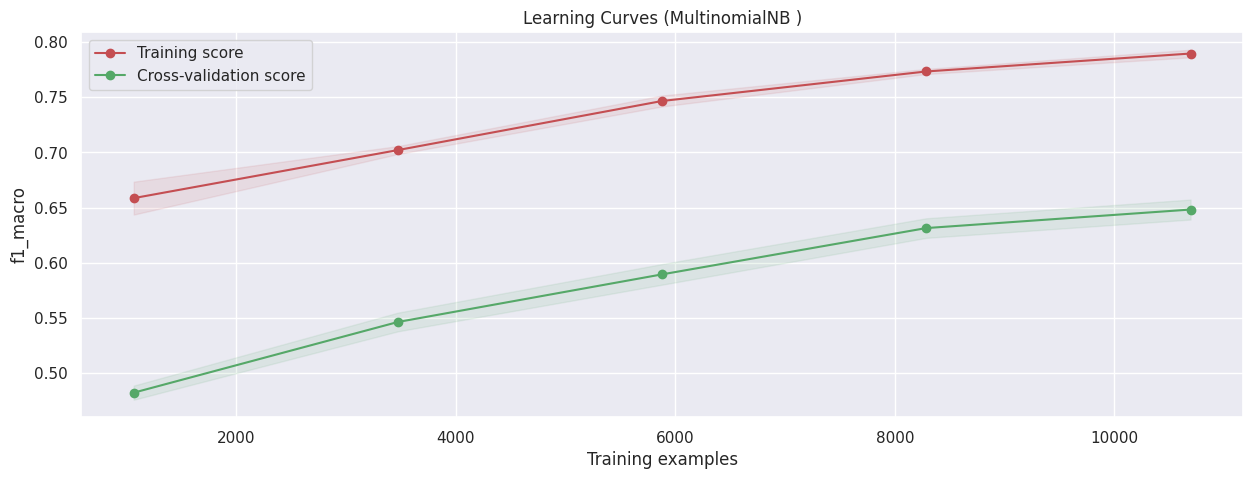

In [54]:
from sklearn.naive_bayes import MultinomialNB

#En este caso no hace falta optimizar ningún parámetro
nb_grid= {} 

nb_text_cls = train_and_evaluate_classifier(train_features, encoded_y_train, MultinomialNB(), nb_grid)

In [55]:
print("Predicting on the test set")
y_pred = nb_text_cls.predict(test_features)

y_pred = le.inverse_transform(y_pred)

Predicting on the test set


Classification Report
              precision    recall  f1-score   support

No offensive       0.89      0.99      0.94      2889
   Offensive       0.84      0.24      0.37       453

    accuracy                           0.89      3342
   macro avg       0.87      0.62      0.66      3342
weighted avg       0.89      0.89      0.86      3342

Confusion matrix, without normalization


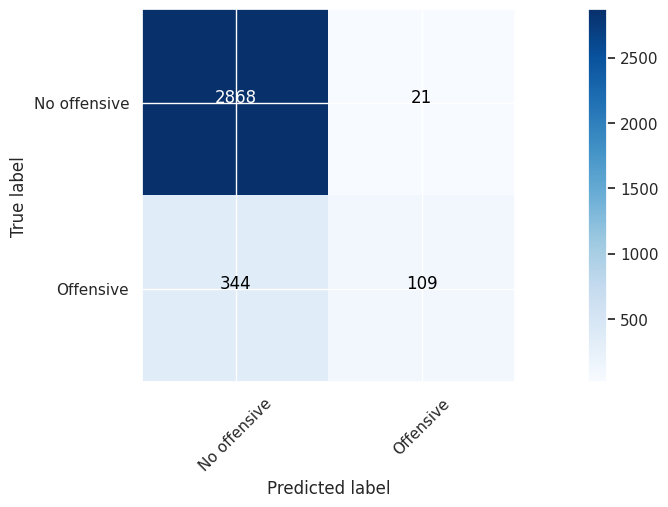

F1 Macro: 0.6571


In [56]:
from sklearn.metrics import f1_score

print("Classification Report")
print(classification_report(y_test, y_pred, target_names=target_labels))
cm = confusion_matrix(y_test, y_pred, labels=target_labels)

plot_confusion_matrix(cm, classes=target_labels)

print("F1 Macro: %.4f" % f1_score(y_test, y_pred, average='macro'))

## SVM

Training model
Fitting 5 folds for each of 6 candidates, totalling 30 fits
[CV 3/5] END ..............C=100, kernel=linear;, score=0.694 total time=   5.9s
[CV 2/5] END ..............C=100, kernel=linear;, score=0.705 total time=   6.1s
[CV 5/5] END ..............C=100, kernel=linear;, score=0.685 total time=   6.2s
[CV 4/5] END ..............C=100, kernel=linear;, score=0.687 total time=   7.2s
[CV 4/5] END ................C=1, kernel=linear;, score=0.736 total time=   5.5s
[CV 1/5] END ...............C=10, kernel=linear;, score=0.709 total time=   5.6s
[CV 2/5] END ...............C=10, kernel=linear;, score=0.722 total time=   5.6s
[CV 3/5] END ...............C=10, kernel=linear;, score=0.725 total time=   5.7s
[CV 5/5] END ...............C=10, kernel=linear;, score=0.717 total time=   5.5s
[CV 1/5] END ................C=1, kernel=linear;, score=0.747 total time=   5.2s
[CV 5/5] END ................C=1, kernel=linear;, score=0.745 total time=   5.8s
[CV 2/5] END ................C=1, 

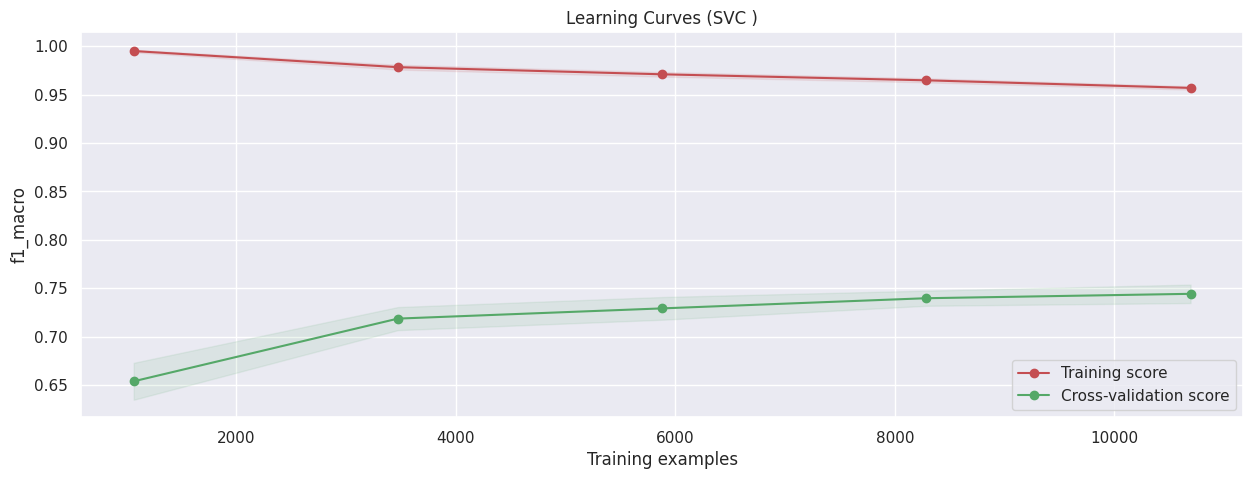

In [57]:
# SVM
from sklearn.svm import SVC

svm_grid = [
  {'C': [1, 10, 100], 'kernel': ['linear']},
  {'C': [10, 100, 1000], 'gamma': [0.0001], 'kernel': ['rbf']},
 ]

svm_cls = train_and_evaluate_classifier(train_features, encoded_y_train, SVC(class_weight='balanced'), svm_grid)

In [58]:
print("Best estimator found by grid search:")
print(svm_cls.best_estimator_)

Best estimator found by grid search:
SVC(C=1, class_weight='balanced', kernel='linear')


In [59]:
print("Predicting sentiment reviews on the test set")
y_pred = svm_cls.predict(test_features)

# Se deshace la transformación de las predicciones para obtener las predicciones como negativa o positiva
y_pred = le.inverse_transform(y_pred)

Predicting sentiment reviews on the test set


Classification Report
              precision    recall  f1-score   support

No offensive       0.94      0.91      0.92      2889
   Offensive       0.52      0.63      0.57       453

    accuracy                           0.87      3342
   macro avg       0.73      0.77      0.75      3342
weighted avg       0.88      0.87      0.88      3342

Confusion matrix, without normalization


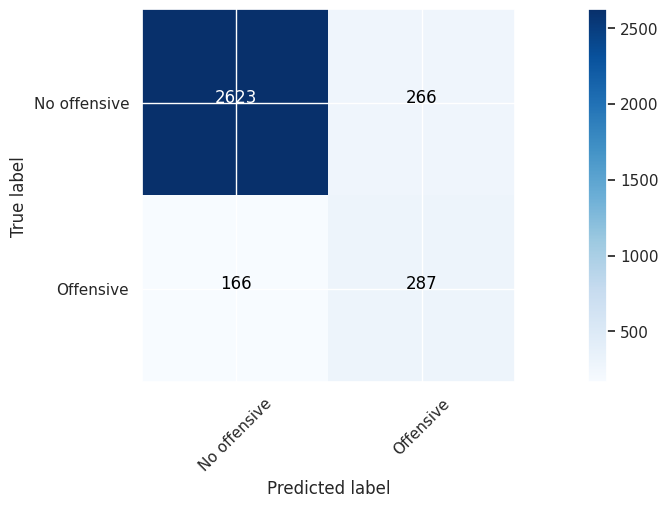

F1 Macro: 0.7472


In [60]:
print("Classification Report")
print(classification_report(y_test, y_pred, target_names=target_labels))
cm = confusion_matrix(y_test, y_pred, labels=target_labels)

plot_confusion_matrix(cm, classes=target_labels)

print("F1 Macro: %.4f" % f1_score(y_test, y_pred, average='macro'))

## MaxEnt

Training model
Fitting 5 folds for each of 14 candidates, totalling 70 fits
[CV 3/5] END ...............C=0.001, penalty=l1;, score=0.464 total time=   0.0s
[CV 5/5] END ...............C=0.001, penalty=l1;, score=0.464 total time=   0.0s
[CV 2/5] END ...............C=0.001, penalty=l1;, score=0.464 total time=   0.0s
[CV 1/5] END ...............C=0.001, penalty=l1;, score=0.464 total time=   0.0s
[CV 4/5] END ...............C=0.001, penalty=l1;, score=0.464 total time=   0.0s
[CV 1/5] END ...............C=0.001, penalty=l2;, score=0.585 total time=   0.0s
[CV 4/5] END ...............C=0.001, penalty=l2;, score=0.603 total time=   0.0s
[CV 3/5] END ...............C=0.001, penalty=l2;, score=0.594 total time=   0.0s
[CV 2/5] END ...............C=0.001, penalty=l2;, score=0.581 total time=   0.0s
[CV 5/5] END ...............C=0.001, penalty=l2;, score=0.594 total time=   0.0s
[CV 3/5] END ................C=0.01, penalty=l1;, score=0.404 total time=   0.0s
[CV 4/5] END ................C=0.

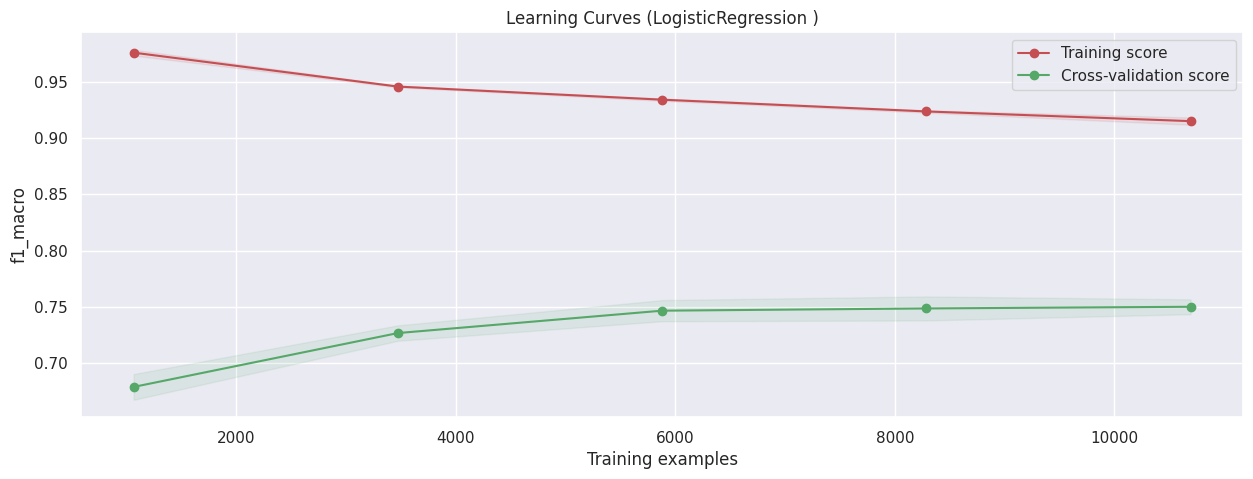

In [61]:
from sklearn.linear_model import LogisticRegression
max_ent_grid= {'penalty': ['l1','l2'], 'C': [0.001,0.01,0.1,1,10,100,1000]}
max_ent_cls = train_and_evaluate_classifier(train_features, encoded_y_train, LogisticRegression(solver='liblinear', class_weight='balanced'), max_ent_grid)

In [62]:
print("Best estimator found by grid search:")
print(max_ent_cls.best_estimator_)

Best estimator found by grid search:
LogisticRegression(C=1, class_weight='balanced', penalty='l2',
                   solver='liblinear')


In [63]:
print("Predicting sentiment on the test set")
y_pred = max_ent_cls.predict(test_features)

# Se deshace la transformación de las predicciones para obtener las predicciones como negativa o positiva
y_pred = le.inverse_transform(y_pred)

Predicting sentiment on the test set


Classification Report
              precision    recall  f1-score   support

No offensive       0.95      0.89      0.92      2889
   Offensive       0.51      0.70      0.59       453

    accuracy                           0.87      3342
   macro avg       0.73      0.80      0.76      3342
weighted avg       0.89      0.87      0.88      3342

Confusion matrix, without normalization


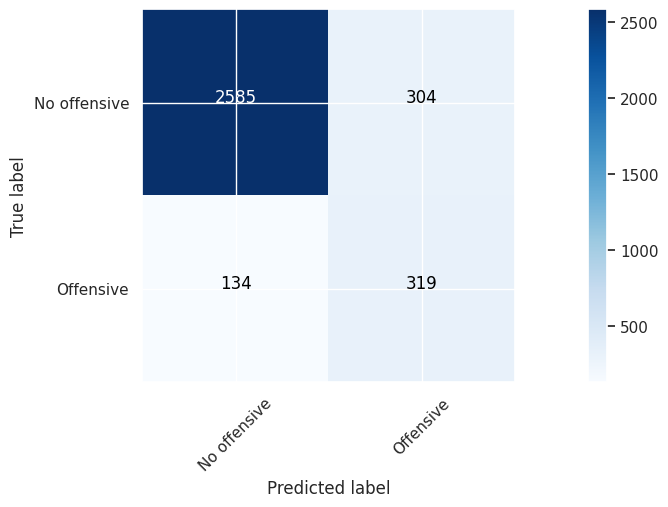

F1 Macro: 0.7574


In [64]:
print("Classification Report")
print(classification_report(y_test, y_pred, target_names=target_labels))
cm = confusion_matrix(y_test, y_pred, labels=target_labels)
 
plot_confusion_matrix(cm, classes=target_labels)

print("F1 Macro: %.4f" % f1_score(y_test, y_pred, average='macro'))

# Pesado con TF-IDF

In [66]:
from sklearn.feature_extraction.text import TfidfTransformer

X_train["all"] = X_train[['clean_comment']].apply(lambda x: ''.join(x), axis=1)
X_test["all"] = X_test[['clean_comment']].apply(lambda x: ''.join(x), axis=1)

count_vect = CountVectorizer(analyzer = "word")
train_features = count_vect.fit_transform(X_train['all'])
test_features = count_vect.transform(X_test['all'])

# Se utiliza L2 (norma euclídea) para normalizar los vectores resultantes
tfidf = TfidfTransformer(norm="l2")
train_text_tfidf_features = tfidf.fit_transform(train_features)
test_text_tfidf_features = tfidf.transform(test_features)                


Training model
Fitting 5 folds for each of 14 candidates, totalling 70 fits
[CV 1/5] END ...............C=0.001, penalty=l1;, score=0.464 total time=   0.0s
[CV 2/5] END ...............C=0.001, penalty=l1;, score=0.464 total time=   0.0s
[CV 3/5] END ...............C=0.001, penalty=l1;, score=0.464 total time=   0.0s
[CV 5/5] END ...............C=0.001, penalty=l1;, score=0.464 total time=   0.0s
[CV 4/5] END ...............C=0.001, penalty=l1;, score=0.464 total time=   0.0s
[CV 1/5] END ...............C=0.001, penalty=l2;, score=0.585 total time=   0.0s
[CV 3/5] END ...............C=0.001, penalty=l2;, score=0.594 total time=   0.0s
[CV 2/5] END ...............C=0.001, penalty=l2;, score=0.581 total time=   0.0s
[CV 4/5] END ...............C=0.001, penalty=l2;, score=0.603 total time=   0.0s
[CV 5/5] END ...............C=0.001, penalty=l2;, score=0.594 total time=   0.0s
[CV 1/5] END ................C=0.01, penalty=l1;, score=0.396 total time=   0.0s
[CV 5/5] END ................C=0.

[CV 1/5] END ................C=1000, penalty=l1;, score=0.679 total time=   1.2s
[CV 4/5] END ................C=1000, penalty=l1;, score=0.691 total time=   0.7s
[CV 2/5] END ................C=1000, penalty=l1;, score=0.706 total time=   0.7s
CV-scores for each grid configuration
F1 Macro: 0.752 (+/-0.012) for params: {'C': 1, 'penalty': 'l2'}
F1 Macro: 0.751 (+/-0.010) for params: {'C': 1, 'penalty': 'l1'}
F1 Macro: 0.747 (+/-0.011) for params: {'C': 10, 'penalty': 'l2'}
F1 Macro: 0.739 (+/-0.008) for params: {'C': 10, 'penalty': 'l1'}
F1 Macro: 0.726 (+/-0.012) for params: {'C': 100, 'penalty': 'l2'}
F1 Macro: 0.726 (+/-0.008) for params: {'C': 0.1, 'penalty': 'l2'}
F1 Macro: 0.719 (+/-0.004) for params: {'C': 0.1, 'penalty': 'l1'}
F1 Macro: 0.717 (+/-0.013) for params: {'C': 100, 'penalty': 'l1'}
F1 Macro: 0.705 (+/-0.016) for params: {'C': 1000, 'penalty': 'l2'}
F1 Macro: 0.692 (+/-0.018) for params: {'C': 1000, 'penalty': 'l1'}
F1 Macro: 0.657 (+/-0.012) for params: {'C': 0.01, 'p

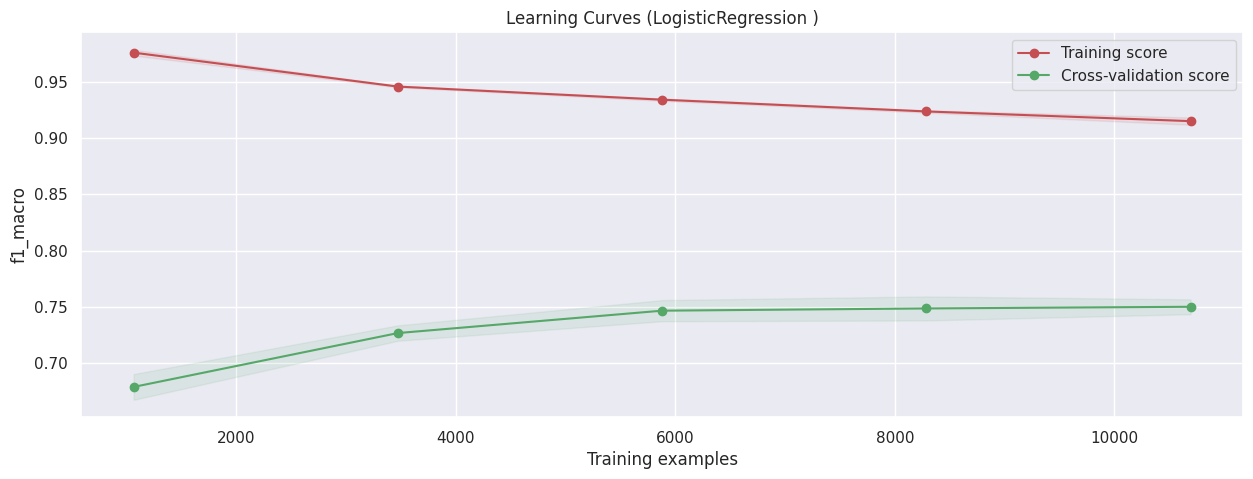

In [71]:
max_ent_grid= {'penalty': ['l1','l2'], 'C': [0.001,0.01,0.1,1,10,100,1000]}
max_ent_tfidf_cls = train_and_evaluate_classifier(train_features, encoded_y_train, LogisticRegression(solver='liblinear', class_weight='balanced'), max_ent_grid)

In [72]:
print("Best estimator found by grid search:")
print(max_ent_tfidf_cls.best_estimator_)

Best estimator found by grid search:
LogisticRegression(C=1, class_weight='balanced', penalty='l2',
                   solver='liblinear')


In [73]:
print("Predicting sentiment on the test set")
y_pred = max_ent_tfidf_cls.predict(test_features)

# Se deshace la transformación de las predicciones para obtener las predicciones como negativa o positiva
y_pred = le.inverse_transform(y_pred)

Predicting sentiment on the test set


Classification Report
              precision    recall  f1-score   support

No offensive       0.95      0.89      0.92      2889
   Offensive       0.51      0.70      0.59       453

    accuracy                           0.87      3342
   macro avg       0.73      0.80      0.76      3342
weighted avg       0.89      0.87      0.88      3342

Confusion matrix, without normalization


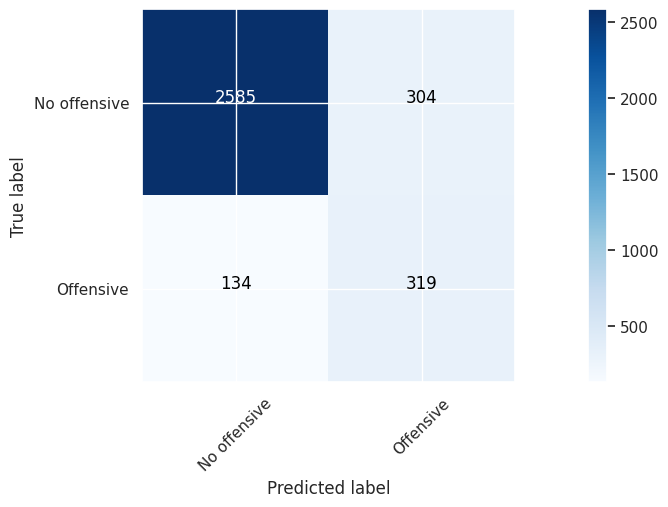

F1 Macro: 0.7574


In [70]:
print("Classification Report")
print(classification_report(y_test, y_pred, target_names=target_labels))
cm = confusion_matrix(y_test, y_pred, labels=target_labels)

plot_confusion_matrix(cm, classes=target_labels)

print("F1 Macro: %.4f" % f1_score(y_test, y_pred, average='macro'))